## Feature Engineering

Systematic evaluation of feature families on top of the 16 percentile-ranked indicator columns
from `stress_score.parquet`. Labels are forward-looking: 1 if SPY drops >= threshold within the
next `LOOKAHEAD` trading days.

**Conclusion:** Raw ranks + 21d/63d momentum (48 features) is the winning feature set.
Every addition tested — lags, level breadth, volatility, breadth of momentum, SPY drawdown —
degraded performance or failed to improve it, due to sample size constraints (~938 positive
events at 60d/8%). Label configuration: 60-day lookahead, 8% drawdown threshold.

The notebook is organized in three parts:
1. Feature family evaluation (sections 1–9): tests lags, momentum, breadth independently
2. Label parameter sweep (section 10): identifies 60d/8% as the best working point for momentum
3. Additional feature testing (sections 11–15): tests volatility, breadth of momentum, and SPY
   drawdown as additions to the momentum set; all are rejected

In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier

N_JOBS = os.cpu_count()
print(f"using {N_JOBS} cores")

using 20 cores


### 1. Load data

In [ ]:
try:
    df = pd.read_parquet("data/processed/stress_score.parquet")
    DOCS_PATH = Path("docs")
except FileNotFoundError:
    df = pd.read_parquet("../data/processed/stress_score.parquet")
    DOCS_PATH = Path("../docs")

df.index = pd.to_datetime(df.index)

INDICATOR_COLS = [
    "T10Y2Y",
    "T10Y3M",
    "T30Y10Y",
    "USALOLITOAASTSAM",
    "UMCSENT",
    "PERMIT",
    "NEWORDER",
    "ICSA",
    "DRCCLACBS",
    "BAMLH0A0HYM2",
    "XLK_XLV",
    "TLT",
    "HG=F",
    "CL=F",
    "EEM",
    "DX=F",
]

df = df.dropna(subset=INDICATOR_COLS)
print(f"{len(df)} rows, {df.index[0].date()} to {df.index[-1].date()}")

5014 rows, 2006-05-01 to 2026-03-19


### 2. Forward drawdown labels

In [ ]:
DRAWDOWN_THRESHOLD = 0.08
LOOKAHEAD = 60

spy = df["SPY"]
future_min = (
    spy[::-1].rolling(window=LOOKAHEAD, min_periods=LOOKAHEAD).min()[::-1].shift(-1)
)
future_drop = future_min / spy - 1

labels_fwd = pd.Series(np.nan, index=spy.index)
valid = future_min.notna()
labels_fwd[valid] = (future_drop[valid] <= -DRAWDOWN_THRESHOLD).astype(float)
labels_fwd = labels_fwd.dropna().astype(int)

print(
    f"{len(labels_fwd)} rows; {labels_fwd.sum()} forward drawdown events ({labels_fwd.mean():.1%})"
)

4954 rows; 938 forward drawdown events (18.9%)


### 3. CV helper and baseline
Reused across all feature sets. Baseline is raw indicator ranks only.

In [ ]:
N_SPLITS = 5
scale_pos_weight = (len(labels_fwd) - labels_fwd.sum()) / labels_fwd.sum()

# best params from forecaster_xgb.ipynb — update if sweep produces different results
XGB_PARAMS = {
    "n_estimators": 200,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": scale_pos_weight,
    "random_state": 42,
    "tree_method": "hist",
    "eval_metric": "logloss",
    "verbosity": 0,
}


def run_cv(X, y, params=XGB_PARAMS, n_splits=N_SPLITS, gap=LOOKAHEAD):
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    aucs, briers = [], []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if y_train.nunique() < 2 or y_test.nunique() < 2:
            continue

        model = XGBClassifier(**params)
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]

        aucs.append(roc_auc_score(y_test, proba))
        briers.append(brier_score_loss(y_test, proba))

    return {
        "mean_auc": np.mean(aucs),
        "std_auc": np.std(aucs),
        "mean_brier": np.mean(briers),
    }


X_base = df.loc[labels_fwd.index, INDICATOR_COLS]
baseline = run_cv(X_base, labels_fwd)
print(
    f"baseline (raw ranks)  AUC: {baseline['mean_auc']:.4f} +/- {baseline['std_auc']:.4f}  Brier: {baseline['mean_brier']:.4f}"
)

baseline (raw ranks)  AUC: 0.4789 +/- 0.1998  Brier: 0.2039


### 4. Lags
Where each indicator stood 5, 21, and 63 trading days ago. Adds directional context:
a high rank that was also high 63 days ago is a stable environment; one that was low
63 days ago is a fast deterioration.

In [ ]:
LAG_WINDOWS = [5, 21, 63]

ranks = df[INDICATOR_COLS]
lag_frames = [ranks]
for w in LAG_WINDOWS:
    lagged = ranks.shift(w).rename(columns={c: f"{c}_lag{w}" for c in INDICATOR_COLS})
    lag_frames.append(lagged)

X_lags = pd.concat(lag_frames, axis=1).loc[labels_fwd.index].dropna()
y_lags = labels_fwd.loc[X_lags.index]

print(f"{X_lags.shape[1]} features, {len(X_lags)} rows after dropping lag warmup")

result_lags = run_cv(X_lags, y_lags)
print(
    f"raw ranks + lags      AUC: {result_lags['mean_auc']:.4f} +/- {result_lags['std_auc']:.4f}  Brier: {result_lags['mean_brier']:.4f}"
)

64 features, 4891 rows after dropping lag warmup
raw ranks + lags      AUC: 0.4630 +/- 0.1489  Brier: 0.1787


### 5. Momentum
Change in rank over 21 and 63 days: `rank[t] - rank[t-w]`. Positive = stress building,
negative = stress easing. Captures rate of change rather than level.

In [ ]:
MOM_WINDOWS = [21, 63]

mom_frames = [ranks]
for w in MOM_WINDOWS:
    mom = (ranks - ranks.shift(w)).rename(
        columns={c: f"{c}_mom{w}" for c in INDICATOR_COLS}
    )
    mom_frames.append(mom)

X_mom = pd.concat(mom_frames, axis=1).loc[labels_fwd.index].dropna()
y_mom = labels_fwd.loc[X_mom.index]

print(f"{X_mom.shape[1]} features, {len(X_mom)} rows after dropping momentum warmup")

result_mom = run_cv(X_mom, y_mom)
print(
    f"raw ranks + momentum  AUC: {result_mom['mean_auc']:.4f} +/- {result_mom['std_auc']:.4f}  Brier: {result_mom['mean_brier']:.4f}"
)

48 features, 4891 rows after dropping momentum warmup
raw ranks + momentum  AUC: 0.6385 +/- 0.1504  Brier: 0.1564


### 6. Breadth
Share of the 16 indicators above their 126-day (6-month) rolling mean. A single indicator
spiking is noise; broad deterioration across multiple indicators is a stronger signal.

In [ ]:
BREADTH_WINDOW = 126

rolling_mean = ranks.rolling(window=BREADTH_WINDOW, min_periods=BREADTH_WINDOW).mean()
above_mean = (ranks > rolling_mean).astype(float)
breadth = above_mean.mean(axis=1).rename("breadth")

X_breadth = pd.concat([ranks, breadth], axis=1).loc[labels_fwd.index].dropna()
y_breadth = labels_fwd.loc[X_breadth.index]

print(f"{X_breadth.shape[1]} features, {len(X_breadth)} rows")

result_breadth = run_cv(X_breadth, y_breadth)
print(
    f"raw ranks + breadth   AUC: {result_breadth['mean_auc']:.4f} +/- {result_breadth['std_auc']:.4f}  Brier: {result_breadth['mean_brier']:.4f}"
)

17 features, 4954 rows
raw ranks + breadth   AUC: 0.5331 +/- 0.1663  Brier: 0.1874


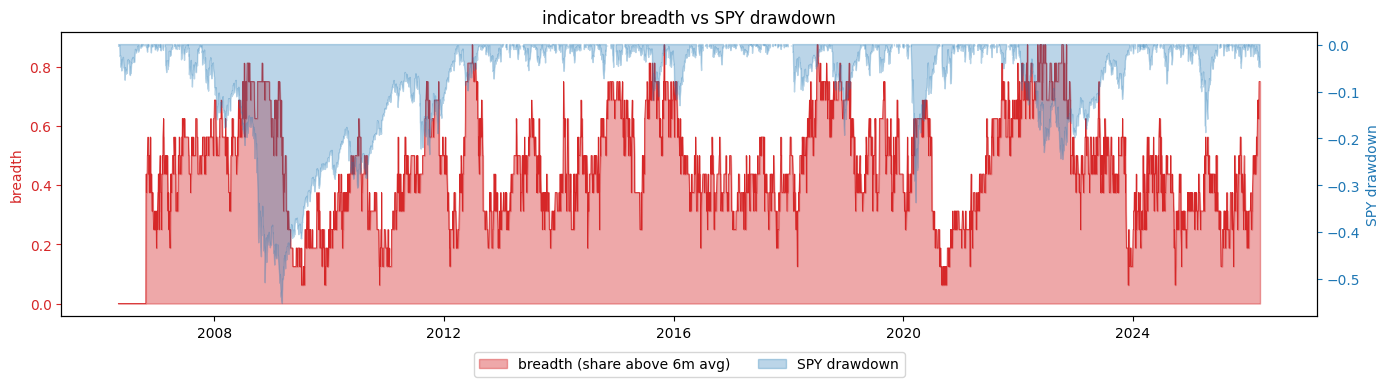

In [ ]:
# visualize breadth vs SPY drawdown
coincident_dd = spy / spy.cummax() - 1

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.fill_between(
    breadth.index,
    breadth,
    alpha=0.4,
    color="#d62728",
    label="breadth (share above 6m avg)",
)
ax1.plot(breadth.index, breadth, color="#d62728", linewidth=0.6)
ax2.fill_between(
    coincident_dd.index,
    coincident_dd,
    0,
    where=coincident_dd < 0,
    alpha=0.3,
    color="#1f77b4",
    label="SPY drawdown",
)

ax1.set_ylabel("breadth", color="#d62728")
ax2.set_ylabel("SPY drawdown", color="#1f77b4")
ax1.tick_params(axis="y", colors="#d62728")
ax2.tick_params(axis="y", colors="#1f77b4")
ax1.set_title("indicator breadth vs SPY drawdown")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
)
plt.tight_layout()
plt.show()

### 7. Combined feature set
All three families together: raw ranks + lags + momentum + breadth.

In [ ]:
all_frames = [ranks]

for w in LAG_WINDOWS:
    all_frames.append(
        ranks.shift(w).rename(columns={c: f"{c}_lag{w}" for c in INDICATOR_COLS})
    )

for w in MOM_WINDOWS:
    all_frames.append(
        (ranks - ranks.shift(w)).rename(
            columns={c: f"{c}_mom{w}" for c in INDICATOR_COLS}
        )
    )

all_frames.append(breadth)

X_all = pd.concat(all_frames, axis=1).loc[labels_fwd.index].dropna()
y_all = labels_fwd.loc[X_all.index]

print(f"{X_all.shape[1]} features, {len(X_all)} rows")

result_all = run_cv(X_all, y_all)
print(
    f"all features          AUC: {result_all['mean_auc']:.4f} +/- {result_all['std_auc']:.4f}  Brier: {result_all['mean_brier']:.4f}"
)

97 features, 4891 rows
all features          AUC: 0.5271 +/- 0.1451  Brier: 0.1711


### 8. Summary

In [ ]:
results = [
    ("baseline (raw ranks)", baseline, len(X_base)),
    ("+ lags", result_lags, len(X_lags)),
    ("+ momentum", result_mom, len(X_mom)),
    ("+ breadth", result_breadth, len(X_breadth)),
    ("all combined", result_all, len(X_all)),
]

print(
    f"{'feature set':<24}  {'n_features':>10}  {'n_rows':>7}  {'AUC':>7}  {'std':>6}  {'Brier':>7}"
)
print("-" * 70)
feature_counts = [
    X_base.shape[1],
    X_lags.shape[1],
    X_mom.shape[1],
    X_breadth.shape[1],
    X_all.shape[1],
]
for (label, r, n_rows), n_feat in zip(results, feature_counts):
    print(
        f"{label:<24}  {n_feat:>10}  {n_rows:>7}  "
        f"{r['mean_auc']:>7.4f}  {r['std_auc']:>6.4f}  {r['mean_brier']:>7.4f}"
    )

feature set               n_features   n_rows      AUC     std    Brier
----------------------------------------------------------------------
baseline (raw ranks)              16     4954   0.4789  0.1998   0.2039
+ lags                            64     4891   0.4630  0.1489   0.1787
+ momentum                        48     4891   0.6385  0.1504   0.1564
+ breadth                         17     4954   0.5331  0.1663   0.1874
all combined                      97     4891   0.5271  0.1451   0.1711


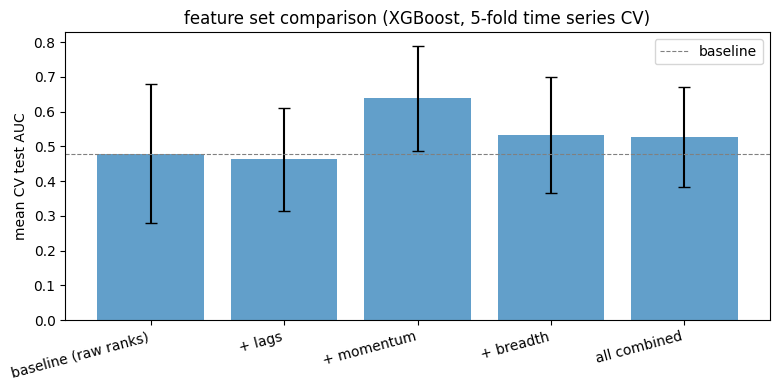

In [ ]:
labels_plot = [r[0] for r in results]
aucs = [r[1]["mean_auc"] for r in results]
stds = [r[1]["std_auc"] for r in results]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(labels_plot))
ax.bar(x, aucs, yerr=stds, color="#1f77b4", alpha=0.7, capsize=4)
ax.axhline(
    baseline["mean_auc"], color="grey", linewidth=0.8, linestyle="--", label="baseline"
)
ax.set_xticks(x)
ax.set_xticklabels(labels_plot, rotation=15, ha="right")
ax.set_ylabel("mean CV test AUC")
ax.set_title("feature set comparison (XGBoost, 5-fold time series CV)")
ax.legend()
plt.tight_layout()
plt.show()

### 9. Feature importance (best feature set)
Fit on the full dataset to see which engineered features the model relies on most.

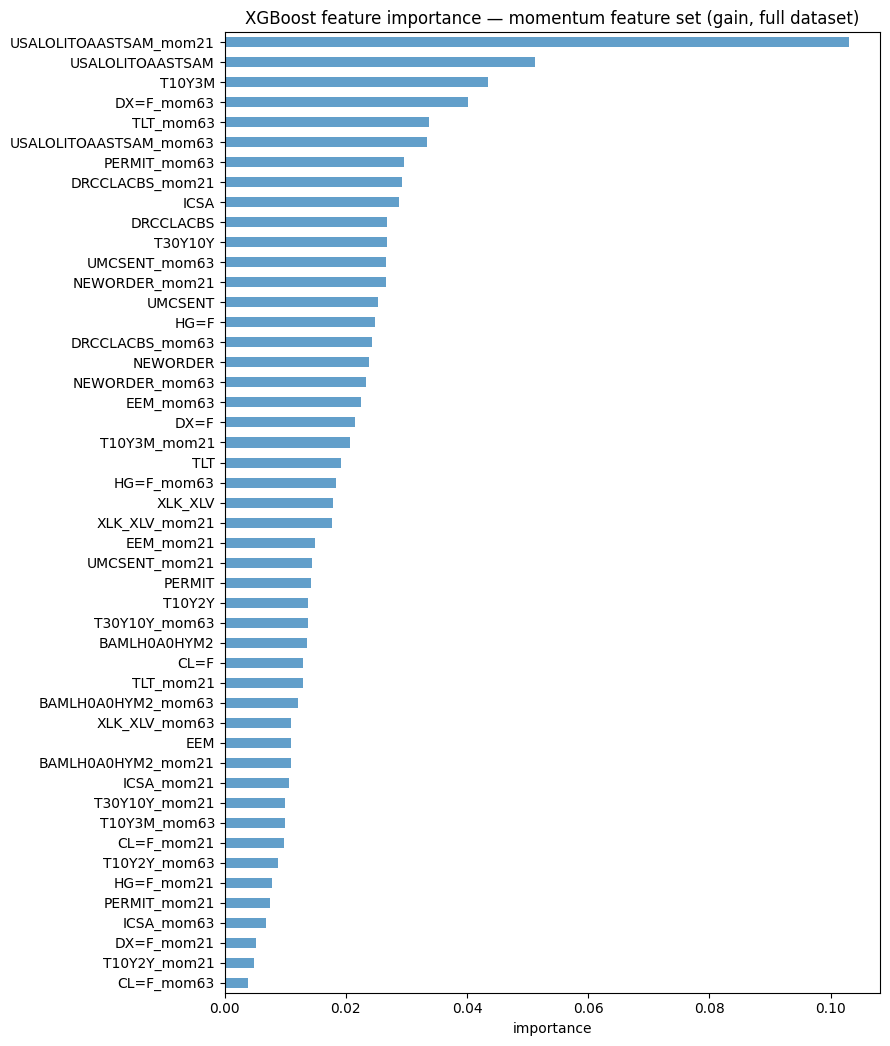

top 10:
USALOLITOAASTSAM_mom21    0.103018
USALOLITOAASTSAM          0.051247
T10Y3M                    0.043439
DX=F_mom63                0.040221
TLT_mom63                 0.033759
USALOLITOAASTSAM_mom63    0.033433
PERMIT_mom63              0.029563
DRCCLACBS_mom21           0.029297
ICSA                      0.028859
DRCCLACBS                 0.026830


In [ ]:
# momentum is the winning feature set from the evaluation above
best_X, best_y = X_mom, y_mom

final_model = XGBClassifier(**XGB_PARAMS)
final_model.fit(best_X, best_y)

importances = pd.Series(final_model.feature_importances_, index=best_X.columns)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, max(4, len(importances) * 0.22)))
importances.plot.barh(ax=ax, color="#1f77b4", alpha=0.7)
ax.invert_yaxis()
ax.set_title("XGBoost feature importance — momentum feature set (gain, full dataset)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

print("top 10:")
print(importances.head(10).to_string())

### 10. Lookahead and threshold sweep

Momentum is the clear winner at the default 60d/10% label configuration. Before fixing the
feature set, we sweep `LOOKAHEAD` (20–120 days) and `DRAWDOWN_THRESHOLD` (5–20%) to find the
label definition where momentum provides the most lift. The XGB params are held fixed; only
the label definition changes. `TimeSeriesSplit(gap=lookahead)` adjusts per job so leakage
prevention matches the horizon.

In [ ]:
LOOKAHEADS = [20, 40, 60, 90, 120]
THRESHOLDS = [0.05, 0.08, 0.10, 0.15, 0.20]

BASE_XGB = {
    "n_estimators": 200,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "tree_method": "hist",
    "eval_metric": "logloss",
    "verbosity": 0,
}


def _sweep_job(lookahead, threshold, spy, ranks, indicator_cols, n_splits=5):
    future_min = (
        spy[::-1].rolling(window=lookahead, min_periods=lookahead).min()[::-1].shift(-1)
    )
    future_drop = future_min / spy - 1

    labels = pd.Series(np.nan, index=spy.index)
    valid = future_min.notna()
    labels[valid] = (future_drop[valid] <= -threshold).astype(float)
    labels = labels.dropna().astype(int)

    if labels.sum() < n_splits * 2:
        return None

    n_pos = labels.sum()
    n_neg = len(labels) - n_pos
    params = {**BASE_XGB, "scale_pos_weight": n_neg / n_pos}

    def cv(X, y):
        tscv = TimeSeriesSplit(n_splits=n_splits, gap=lookahead)
        aucs = []
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            if y_train.nunique() < 2 or y_test.nunique() < 2:
                continue
            m = XGBClassifier(**params)
            m.fit(X_train, y_train)
            aucs.append(roc_auc_score(y_test, m.predict_proba(X_test)[:, 1]))
        return float(np.mean(aucs)) if aucs else float("nan")

    X_raw = ranks.loc[labels.index, indicator_cols]

    mom_frames = [X_raw]
    for w in [21, 63]:
        mom = (ranks[indicator_cols] - ranks[indicator_cols].shift(w)).rename(
            columns={c: f"{c}_mom{w}" for c in indicator_cols}
        )
        mom_frames.append(mom)
    X_mom = pd.concat(mom_frames, axis=1).loc[labels.index].dropna()
    y_mom = labels.loc[X_mom.index]
    X_raw_aligned = X_raw.loc[X_mom.index]
    y_raw_aligned = labels.loc[X_mom.index]

    auc_base = cv(X_raw_aligned, y_raw_aligned)
    auc_mom = cv(X_mom, y_mom)

    return {
        "lookahead": lookahead,
        "threshold": threshold,
        "n_events": int(n_pos),
        "event_rate": round(n_pos / len(labels), 3),
        "auc_base": round(auc_base, 4),
        "auc_mom": round(auc_mom, 4),
        "lift": round(auc_mom - auc_base, 4),
    }


combos = [(la, th) for la in LOOKAHEADS for th in THRESHOLDS]
raw_results = Parallel(n_jobs=N_JOBS)(
    delayed(_sweep_job)(la, th, spy, ranks, INDICATOR_COLS) for la, th in combos
)
sweep_df = pd.DataFrame([r for r in raw_results if r is not None])
print(f"{len(sweep_df)} valid combinations")

25 valid combinations


In [ ]:
print(
    f"{'lookahead':>9}  {'threshold':>9}  {'events':>7}  {'rate':>6}  {'base AUC':>9}  {'mom AUC':>8}  {'lift':>7}"
)
print("-" * 70)
for _, row in sweep_df.sort_values("lift", ascending=False).iterrows():
    print(
        f"{int(row['lookahead']):>9}  {row['threshold']:>9.0%}  {int(row['n_events']):>7}  "
        f"{row['event_rate']:>6.1%}  {row['auc_base']:>9.4f}  {row['auc_mom']:>8.4f}  {row['lift']:>7.4f}"
    )

lookahead  threshold   events    rate   base AUC   mom AUC     lift
----------------------------------------------------------------------
       40        20%      101    2.0%     0.3472    0.7870   0.4398
       20        20%       43    0.9%     0.1217    0.3728   0.2512
       60        20%      158    3.2%     0.3127    0.5572   0.2445
       20        10%      215    4.3%     0.3331    0.4903   0.1572
      120         5%     1998   40.8%     0.4346    0.5652   0.1306
       60         8%      938   18.9%     0.5169    0.6393   0.1224
       40         8%      701   14.1%     0.4804    0.5938   0.1134
       40        10%      482    9.7%     0.4800    0.5883   0.1083
       90         8%     1177   23.9%     0.4735    0.5748   0.1013
       90         5%     1816   36.9%     0.4776    0.5781   0.1005
       20         8%      368    7.4%     0.3917    0.4721   0.0804
       90        20%      235    4.8%     0.0895    0.1641   0.0746
       60        10%      711   14.4%     0.4

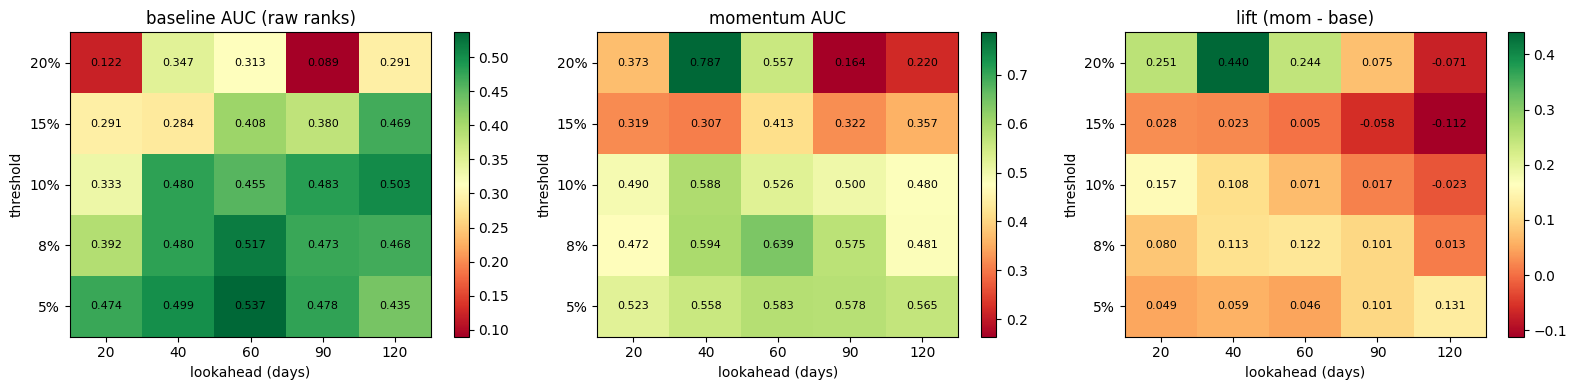

In [ ]:
def to_grid(col):
    return sweep_df.pivot(
        index="threshold", columns="lookahead", values=col
    ).sort_index(ascending=False)


grid_base = to_grid("auc_base")
grid_mom = to_grid("auc_mom")
grid_lift = to_grid("lift")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, grid, title, cmap in [
    (axes[0], grid_base, "baseline AUC (raw ranks)", "RdYlGn"),
    (axes[1], grid_mom, "momentum AUC", "RdYlGn"),
    (axes[2], grid_lift, "lift (mom - base)", "RdYlGn"),
]:
    vmin, vmax = grid.values.min(), grid.values.max()
    im = ax.imshow(grid.values, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels(grid.columns)
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels([f"{t:.0%}" for t in grid.index])
    ax.set_xlabel("lookahead (days)")
    ax.set_ylabel("threshold")
    ax.set_title(title)
    for i in range(len(grid.index)):
        for j in range(len(grid.columns)):
            ax.text(
                j, i, f"{grid.values[i, j]:.3f}", ha="center", va="center", fontsize=8
            )
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [ ]:
best_lift = sweep_df.loc[sweep_df["lift"].idxmax()]
best_auc = sweep_df.loc[sweep_df["auc_mom"].idxmax()]

print("best by lift (momentum gain over baseline):")
print(
    f"  lookahead={int(best_lift['lookahead'])}d  threshold={best_lift['threshold']:.0%}  "
    f"base={best_lift['auc_base']:.4f}  mom={best_lift['auc_mom']:.4f}  lift={best_lift['lift']:.4f}  "
    f"events={int(best_lift['n_events'])} ({best_lift['event_rate']:.1%})"
)
print()
print("best by absolute momentum AUC:")
print(
    f"  lookahead={int(best_auc['lookahead'])}d  threshold={best_auc['threshold']:.0%}  "
    f"base={best_auc['auc_base']:.4f}  mom={best_auc['auc_mom']:.4f}  lift={best_auc['lift']:.4f}  "
    f"events={int(best_auc['n_events'])} ({best_auc['event_rate']:.1%})"
)
print()
print("working point selected: 60d / 8%")
print(
    row_60_8 := sweep_df[
        (sweep_df.lookahead == 60) & (sweep_df.threshold == 0.08)
    ].iloc[0]
)
print()
print(
    "Note: the 40d/20% result (lift=0.44) is rejected — only 101 positive events across 5 folds\n"
    "gives each test fold ~20 examples, making the AUC estimate unreliable. The 60d/8% config\n"
    "has 938 events, stable CV variance (std 0.15), and meaningful lift (+0.12) over baseline."
)

best by lift (momentum gain over baseline):
  lookahead=40d  threshold=20%  base=0.3472  mom=0.7870  lift=0.4398  events=101 (2.0%)

best by absolute momentum AUC:
  lookahead=40d  threshold=20%  base=0.3472  mom=0.7870  lift=0.4398  events=101 (2.0%)

working point selected: 60d / 8%
lookahead      60.0000
threshold       0.0800
n_events      938.0000
event_rate      0.1890
auc_base        0.5169
auc_mom         0.6393
lift            0.1224
Name: 11, dtype: float64

Note: the 40d/20% result (lift=0.44) is rejected — only 101 positive events across 5 folds
gives each test fold ~20 examples, making the AUC estimate unreliable. The 60d/8% config
has 938 events, stable CV variance (std 0.15), and meaningful lift (+0.12) over baseline.


### 11. Additional feature testing on the momentum set

The sweep identifies 60d/8% as the best working point (momentum AUC 0.6393, lift +0.122).
With the label configuration fixed, we test three additional feature families as potential
additions to the momentum set. Each is tested in isolation against raw ranks first, then
the most promising is tested as a direct addition to momentum.

**Vol21** (rolling 21d std per indicator): captures instability rather than direction.
**Breadth of momentum** (share of indicators with positive 21d momentum): a single-number
summary of how broadly stress is deteriorating across indicators.
**SPY drawdown** (distance from expanding high): regime conditioning on current market state.

In [ ]:
VOL_WINDOW = 21

vol = (
    ranks.rolling(window=VOL_WINDOW, min_periods=VOL_WINDOW)
    .std()
    .rename(columns={c: f"{c}_vol{VOL_WINDOW}" for c in INDICATOR_COLS})
)

X_vol = pd.concat([ranks, vol], axis=1).loc[labels_fwd.index].dropna()
y_vol = labels_fwd.loc[X_vol.index]

print(f"{X_vol.shape[1]} features, {len(X_vol)} rows")
result_vol = run_cv(X_vol, y_vol)
print(
    f"raw ranks + vol{VOL_WINDOW}      AUC: {result_vol['mean_auc']:.4f} +/- {result_vol['std_auc']:.4f}  Brier: {result_vol['mean_brier']:.4f}"
)

32 features, 4934 rows
raw ranks + vol21      AUC: 0.5097 +/- 0.1825  Brier: 0.1890


### 12. Breadth of momentum
Share of the 16 indicators with positive 21-day momentum — how many are actively
deteriorating right now. Combines the breadth and momentum signals into a single
number rather than adding 16 more features.

In [ ]:
mom_21 = ranks - ranks.shift(21)
breadth_mom = (mom_21 > 0).astype(float).mean(axis=1).rename("breadth_mom")

X_bmom = pd.concat([ranks, breadth_mom], axis=1).loc[labels_fwd.index].dropna()
y_bmom = labels_fwd.loc[X_bmom.index]

print(f"{X_bmom.shape[1]} features, {len(X_bmom)} rows")
result_bmom = run_cv(X_bmom, y_bmom)
print(
    f"raw ranks + breadth_mom  AUC: {result_bmom['mean_auc']:.4f} +/- {result_bmom['std_auc']:.4f}  Brier: {result_bmom['mean_brier']:.4f}"
)

17 features, 4954 rows
raw ranks + breadth_mom  AUC: 0.5457 +/- 0.1587  Brier: 0.1945


### 13. SPY current drawdown level
How far SPY is from its all-time expanding high at time t. Directly conditions the
forward label probability — the 60-day distribution looks different at -2% vs -8%.
No lookahead risk: observable at time t.

In [ ]:
spy_drawdown = (spy / spy.cummax() - 1).rename("spy_drawdown")

X_spydd = pd.concat([ranks, spy_drawdown], axis=1).loc[labels_fwd.index].dropna()
y_spydd = labels_fwd.loc[X_spydd.index]

print(f"{X_spydd.shape[1]} features, {len(X_spydd)} rows")
result_spydd = run_cv(X_spydd, y_spydd)
print(
    f"raw ranks + spy_drawdown AUC: {result_spydd['mean_auc']:.4f} +/- {result_spydd['std_auc']:.4f}  Brier: {result_spydd['mean_brier']:.4f}"
)

17 features, 4954 rows
raw ranks + spy_drawdown AUC: 0.5569 +/- 0.1966  Brier: 0.2203


### 14. Momentum + breadth_mom
Testing breadth_mom as a standalone addition to momentum before committing to the feature set.
It's the only new feature with variance low enough (std 0.1587) to potentially add signal
without diluting the momentum set.

In [ ]:
mom_frames_bmom = [ranks]
for w in MOM_WINDOWS:
    mom_frames_bmom.append(
        (ranks - ranks.shift(w)).rename(
            columns={c: f"{c}_mom{w}" for c in INDICATOR_COLS}
        )
    )
mom_frames_bmom.append(breadth_mom)

X_mom_bmom = pd.concat(mom_frames_bmom, axis=1).loc[labels_fwd.index].dropna()
y_mom_bmom = labels_fwd.loc[X_mom_bmom.index]

print(f"{X_mom_bmom.shape[1]} features, {len(X_mom_bmom)} rows")
result_mom_bmom = run_cv(X_mom_bmom, y_mom_bmom)
print(
    f"momentum               AUC: {result_mom['mean_auc']:.4f} +/- {result_mom['std_auc']:.4f}  Brier: {result_mom['mean_brier']:.4f}"
)
print(
    f"momentum + breadth_mom AUC: {result_mom_bmom['mean_auc']:.4f} +/- {result_mom_bmom['std_auc']:.4f}  Brier: {result_mom_bmom['mean_brier']:.4f}"
)

49 features, 4891 rows
momentum               AUC: 0.6385 +/- 0.1504  Brier: 0.1564
momentum + breadth_mom AUC: 0.6193 +/- 0.1539  Brier: 0.1579


### Conclusion

**Final feature set: raw ranks + 21d/63d momentum — 48 features.**

breadth_mom, the most promising candidate, drops momentum AUC from 0.6385 to 0.6193 when
added. With only 938 positive events, the model does not have enough signal to absorb
additional features without overfitting. Every feature family tested either hurt performance
or failed to improve it once momentum was in the set.

**Label configuration: 60-day lookahead, 8% drawdown threshold.**
The threshold sweep confirmed that 8% produces more events (938 vs 711 at 10%) and better
momentum lift (+0.122 vs +0.071) at the 60-day horizon.

**Next step:** re-run the hyperparameter sweep from `forecaster_xgb.ipynb` on this feature
set and label configuration. The current XGB params were tuned on raw ranks with 10% labels
and have not been optimized for momentum features or 8% labels.